<a href="https://colab.research.google.com/github/PalomaSoaresR/FATEC-API-6-SEMESTRE/blob/docs-add-tutorial-notebooks/Mapa_de_Criticidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Análise de Criticidade e Heatmap de Continuidade (ANEEL)

#  Guia: Como Adicionar Novas Concessionárias e Dados

Este guia explica como expandir este notebook para analisar outras distribuidoras ou atualizar os anos de análise.

### 1. Obtenção de Novos Dados da ANEEL
Os links no primeiro bloco de código apontam para o **Portal de Dados Abertos da ANEEL**. Para mudar a abrangência:
1. Vá ao [Portal de Dados Abertos da ANEEL](https://dadosabertos.aneel.gov.br/).
2. Procure por "Indicadores de Continuidade Coletivos".
3. Copie o link do CSV de **Indicadores Reais** (Série Histórica) e de **Limites**.
4. No primeiro bloco de código, substitua `url_real` e `url_limite` pelos novos links.

### 2. Filtrando a Distribuidora e Período
No segundo bloco de código (`cell_id: 2M4zEQL8nymA`), você pode controlar o que será processado:
- **Anos:** Altere a lista `anos_alvo = [2021, 2022, 2023, 2024, 2025]` para o período desejado.
- **Distribuidora:** No merge, o código utiliza a coluna `SigAgente`. Se quiser filtrar apenas uma empresa específica antes do pivot, adicione:
  ```python
  df_real = df_real[df_real['SigAgente'] == 'NOME_DA_EMPRESA']
  ```

### 3. Adicionando Dados Geográficos (Shapefiles/GDB)
Para que o Heatmap funcione para uma nova concessionária, você precisa do arquivo de geometria (GDB ou Shapefile):
1. Obtenha o link do SIGEL (Sistema de Informações Geográficas do Setor Elétrico) ou base similar.
2. No bloco de download do ArcGIS, substitua a `url_arquivo`.
3. **Importante:** Verifique o nome da camada (layer) usando `fiona.listlayers(caminho_gdb)`. No exemplo, usamos `'SSDMT'`, mas outras empresas podem nomear de forma diferente.

### 4. Cruzamento de Dados (Merge)
A chave de ligação entre os dados da ANEEL e os dados geográficos é o **Código do Conjunto**. No código:
- No DataFrame da ANEEL, a coluna é `Conjunto_ID`.
- No GeoDataFrame (GDB), a coluna geralmente é `CONJ`.
- Certifique-se de que ambas as colunas estão no mesmo formato (string) antes de realizar o `merge` no bloco do Heatmap.

### 5. Ajuste das Cores e Metas
No bloco final, você pode ajustar os critérios de criticidade na função `classificar_criticidade`. Se quiser que a cor vermelha apareça apenas para desvios maiores que 20%, basta alterar o valor no `elif`.

In [ ]:
import pandas as pd
import requests
import os

# URLs diretas e oficiais do portal de Dados Abertos da ANEEL (Série 2020-2029 e Limites)
url_real = "https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/4493985c-baea-429c-9df5-3030422c71d7/download/indicadores-continuidade-coletivos-2020-2029.csv"
url_limite = "https://dadosabertos.aneel.gov.br/dataset/d5f0712e-62f6-4736-8dff-9991f10758a7/resource/fd69e1dd-fd66-4269-b60c-cc0b7eb221b4/download/indicadores-continuidade-coletivos-limite.csv"

arq_real = "aneel_realizado.csv"
arq_limite = "aneel_limite.csv"

# Função para bater na ANEEL e baixar
def baixar_aneel(url, nome):
    if not os.path.exists(nome):
        print(f"Baixando {nome} da ANEEL... (Isso pode levar um minutinho)")
        resposta = requests.get(url)
        with open(nome, 'wb') as f:
            f.write(resposta.content)
        print(f"Download de {nome} belezinha! ✅")
    else:
        print(f"{nome} já tá na mão! Pulando download. ⚡")

baixar_aneel(url_real, arq_real)
baixar_aneel(url_limite, arq_limite)

Baixando aneel_realizado.csv da ANEEL... (Isso pode levar um minutinho)
Download de aneel_realizado.csv belezinha! ✅
Baixando aneel_limite.csv da ANEEL... (Isso pode levar um minutinho)
Download de aneel_limite.csv belezinha! ✅


In [ ]:
import pandas as pd
import numpy as np

print("Carregando os CSVs no Pandas...")
df_real = pd.read_csv('aneel_realizado.csv', sep=';', encoding='latin1')
df_lim = pd.read_csv('aneel_limite.csv', sep=';', encoding='latin1')

# Filtrando para os últimos 5 anos (2021 a 2025)
anos_alvo = [2021, 2022, 2023, 2024, 2025]
df_real = df_real[df_real['AnoIndice'].isin(anos_alvo)]
df_lim = df_lim[df_lim['AnoLimiteQualidade'].isin(anos_alvo)]

df_real = df_real.rename(columns={'VlrIndiceEnviado': 'Valor_Realizado'})
df_lim = df_lim.rename(columns={'VlrLimite': 'Valor_Limite', 'AnoLimiteQualidade': 'AnoIndice'})

df_real['Valor_Realizado'] = df_real['Valor_Realizado'].astype(str).str.replace(',', '.').astype(float)
df_lim['Valor_Limite'] = df_lim['Valor_Limite'].astype(str).str.replace(',', '.').astype(float)

# Converter a coluna 'IdeConjUndConsumidoras' para string em ambos os DataFrames antes do merge
df_real['IdeConjUndConsumidoras'] = df_real['IdeConjUndConsumidoras'].astype(str)
df_lim['IdeConjUndConsumidoras'] = df_lim['IdeConjUndConsumidoras'].astype(str)

# Adicionando 'IdeConjUndConsumidoras' às chaves de junção
chaves_join = ['SigAgente', 'DscConjUndConsumidoras', 'IdeConjUndConsumidoras', 'SigIndicador', 'AnoIndice']
df_completo = pd.merge(df_real, df_lim, on=chaves_join, how='inner')

# Pivotando para DEC e FEC virarem colunas na mesma linha
# IMPORTANTE: Colocamos o 'AnoIndice' no index para manter o histórico separado por ano!
df_tratado = df_completo.pivot_table(
    index=['SigAgente', 'DscConjUndConsumidoras', 'IdeConjUndConsumidoras', 'AnoIndice'],
    columns='SigIndicador',
    values=['Valor_Realizado', 'Valor_Limite'],
    aggfunc={
        'Valor_Realizado': 'sum',  # Soma os 12 meses para dar o total do ano
        'Valor_Limite': 'mean'     # Tira a média para manter o valor original do limite anual
    }
).reset_index()
df_tratado.columns = [f"{col[1]}_{col[0]}" if col[1] else col[0] for col in df_tratado.columns]

df_tratado = df_tratado.rename(columns={
    'IdeConjUndConsumidoras': 'Conjunto_ID',
    'SigAgente': 'Distribuidora',
    'DscConjUndConsumidoras': 'Conjunto',
    'AnoIndice': 'Ano',
    'DEC_Valor_Realizado': 'DEC_realizado',
    'DEC_Valor_Limite': 'DEC_limite',
    'FEC_Valor_Realizado': 'FEC_realizado',
    'FEC_Valor_Limite': 'FEC_limite'
})

df_tratado = df_tratado.dropna(subset=['DEC_realizado', 'DEC_limite', 'FEC_realizado', 'FEC_limite'])

print("Dados dos últimos 5 anos tratados e cruzados com sucesso!")
display(df_tratado)

Carregando os CSVs no Pandas...


/tmp/ipykernel_2659/2255681259.py:6: DtypeWarning: Columns (3) have mixed types. Specify dtype option on import or set low_memory=False.
  df_lim = pd.read_csv('aneel_limite.csv', sep=';', encoding='latin1')


Dados dos últimos 5 anos tratados e cruzados com sucesso!


,Distribuidora,Conjunto,Conjunto_ID,Ano,DEC_limite,FEC_limite,DEC_realizado,FEC_realizado
0,AME,ALTO SOLIMÕES,12584,2021.0,75.0,62.0,53.35,72.79
1,AME,ALTO SOLIMÕES,12584,2022.0,75.0,62.0,50.01,66.37
2,AME,ALTO SOLIMÕES,12584,2023.0,75.0,62.0,37.50,41.12
3,AME,ALTO SOLIMÕES,12584,2024.0,75.0,62.0,46.59,42.88
4,AME,ALTO SOLIMÕES,12584,2025.0,70.0,57.0,59.51,39.41
...,...,...,...,...,...,...,...,...
15609,UHENPAL,Faxinal do Soturno,13683,2021.0,15.0,11.0,10.18,7.14
15610,UHENPAL,Faxinal do Soturno,13683,2022.0,15.0,10.0,6.62,6.71
15611,UHENPAL,Faxinal do Soturno,13683,2023.0,15.0,10.0,8.88,8.63
15612,UHENPAL,Faxinal do Soturno,13683,2024.0,15.0,9.0,8.72,5.22


In [ ]:
caminho_saida = 'dados_aneel_prontos_para_calculo.csv'
df_tratado.to_csv(caminho_saida, index=False, sep=';', decimal=',')
print(f"Base redonda salva em: {caminho_saida}")

Base redonda salva em: dados_aneel_prontos_para_calculo.csv


In [ ]:
df_calculo = pd.read_csv(caminho_saida, sep=';', decimal=',')

def calcula_desvio(realizado, limite):
    limite = np.where(limite == 0, np.nan, limite)
    calculo = ((realizado - limite) / limite) * 100
    return np.maximum(0, calculo)

df_calculo['Desvio_DEC'] = calcula_desvio(df_calculo['DEC_realizado'], df_calculo['DEC_limite'])
df_calculo['Desvio_FEC'] = calcula_desvio(df_calculo['FEC_realizado'], df_calculo['FEC_limite'])
df_calculo['Score_Criticidade'] = df_calculo['Desvio_DEC'] + df_calculo['Desvio_FEC']

df_resultado = df_calculo.sort_values(by='Score_Criticidade', ascending=False)

display(df_resultado)

,Distribuidora,Conjunto,Conjunto_ID,Ano,DEC_limite,FEC_limite,DEC_realizado,FEC_realizado,Desvio_DEC,Desvio_FEC,Score_Criticidade
10812,EQUATORIAL GO,CABRIUVA S2,15730,2022.0,12.0,11.0,154.97,31.24,1191.416667,184.000000,1375.416667
11094,EQUATORIAL GO,ITAJA S1,14926,2023.0,16.0,10.0,130.76,47.10,717.250000,371.000000,1088.250000
11125,EQUATORIAL GO,ITUMBIARA VELHA S2,15743,2023.0,14.0,9.0,125.35,25.37,795.357143,181.888889,977.246032
10813,EQUATORIAL GO,CABRIUVA S2,15730,2023.0,12.0,10.0,109.14,26.23,809.500000,162.300000,971.800000
554,CEEE-D,UTE PRESIDENTE MÉDICI,12576,2024.0,15.0,9.0,110.02,39.16,633.466667,335.111111,968.577778
...,...,...,...,...,...,...,...,...,...,...,...
7893,ELETROPAULO,NAÇÕES,12947,2025.0,7.0,5.0,6.17,3.65,0.000000,0.000000,0.000000
7894,ELETROPAULO,NOVO BANDEIRANTES,17111,2024.0,5.0,3.0,4.71,1.85,0.000000,0.000000,0.000000
7895,ELETROPAULO,NOVO BANDEIRANTES,17111,2025.0,5.0,3.0,3.76,1.54,0.000000,0.000000,0.000000
7896,ELETROPAULO,NOVO MUNDO,12948,2021.0,6.0,5.0,5.43,2.62,0.000000,0.000000,0.000000


# Geração do Heatmap
usando a base Enel_SP

In [ ]:

import requests
import os
import zipfile

# URL fornecida pelo usuário
url_arquivo = "https://www.arcgis.com/sharing/rest/content/items/afa54a48397745a2b2fbc550880aa2d7/data"
nome_arquivo_zip = "dados_ssdmt.zip"

print(f"Baixando o arquivo de: {url_arquivo}")

# Baixar o arquivo
resposta = requests.get(url_arquivo, stream=True)
resposta.raise_for_status() # Levanta um erro para status de resposta HTTP ruins

with open(nome_arquivo_zip, 'wb') as f:
    for chunk in resposta.iter_content(chunk_size=8192):
        f.write(chunk)

print(f"Download completo! Arquivo salvo como: {nome_arquivo_zip}")

# Criar um diretório para a extração, se não existir
dir_extracao = "SSDMT_extraido"
os.makedirs(dir_extracao, exist_ok=True)

print(f"Extraindo '{nome_arquivo_zip}' para '{dir_extracao}'...")

# Extrair o conteúdo do arquivo ZIP
with zipfile.ZipFile(nome_arquivo_zip, 'r') as zip_ref:
    zip_ref.extractall(dir_extracao)

print("Extração completa!")

Baixando o arquivo de: https://www.arcgis.com/sharing/rest/content/items/afa54a48397745a2b2fbc550880aa2d7/data
Download completo! Arquivo salvo como: dados_ssdmt.zip
Extraindo 'dados_ssdmt.zip' para 'SSDMT_extraido'...
Extração completa!


In [ ]:
#Download das bibliotecas para lidar
import sys
!{sys.executable} -m pip install geopandas
!{sys.executable} -m pip install fiona

In [ ]:
import geopandas as gpd
import os
import fiona

dir_extracao = "SSDMT_extraido"
nome_gdb = "Enel_SP_390_2024-12-31_V11_20250926-0906.gdb"
caminho_gdb = os.path.join(dir_extracao, nome_gdb)

# A camada que você especificou para carregar
camada_para_carregar = 'SSDMT'

print(f"Tentando carregar a camada '{camada_para_carregar}' do GeoDatabase: {caminho_gdb}")

# Carregar a camada específica do GeoDatabase
try:
    gdf_ssdmt = gpd.read_file(caminho_gdb, layer=camada_para_carregar)
    print(f"Camada '{camada_para_carregar}' carregada com sucesso!")
    display(gdf_ssdmt.head())
except Exception as e:
    print(f"Erro ao carregar a camada '{camada_para_carregar}': {e}")
    print(f"Verificando as camadas disponíveis no GDB: {fiona.listlayers(caminho_gdb)}")

Tentando carregar a camada 'SSDMT' do GeoDatabase: SSDMT_extraido/Enel_SP_390_2024-12-31_V11_20250926-0906.gdb
Camada 'SSDMT' carregada com sucesso!


,COD_ID,PN_CON_1,PN_CON_2,CTMT,CT_COD_OP,UNI_TR_AT,SUB,CONJ,ARE_LOC,DIST,...,TIP_CND,POS,ODI,TI,CM,SITCONT,COMP,DESCR,Shape_Length,geometry
0,100719646S1,496392,496283,GUA0109,GUA0109,DGUA-EQ-TR2,DGUA,12913,UB,390,...,904,PD,110001,40,999,AT1,9.96,,0.000091,"MULTILINESTRING ((-46.69943 -23.69496, -46.699..."
1,100719741S1,919707,3700901F,CPE0105,CPE0105,DCPE-EQ-TR2,DCPE,12866,UB,390,...,1390,PD,110001,40,999,AT1,32.00,,0.000289,"MULTILINESTRING ((-46.54248 -23.6528, -46.5424..."
2,100719741S2,3700901F,919706,CPE0105,CPE0105,DCPE-EQ-TR2,DCPE,12866,UB,390,...,1390,PD,110001,40,999,AT1,6.00,,0.000054,"MULTILINESTRING ((-46.54248 -23.65309, -46.542..."
3,101461743S1,10968051,467601,GJU0110,GJU0110,DGJU-EQ-TR2,DGJU,12911,UB,390,...,2944,PD,110001,40,999,AT1,6.94,,0.000064,"MULTILINESTRING ((-46.70759 -23.6294, -46.7076..."
4,101461994S1,10977066,,CLA0109,CLA0109,DCLA-EQ-TR1,DCLA,12887,UB,390,...,2716,PD,120001,42,999,AT1,68.68,,0.000654,"MULTILINESTRING ((-46.57792 -23.55085, -46.578..."


In [ ]:
import matplotlib.pyplot as plt

# Filtrar df_resultado para o ano de 2024
df_resultado_2024 = df_resultado[df_resultado['Ano'] == 2024.0].copy()

# Verificar e converter tipos de dados para a junção
# Assumindo que 'CONJ' em gdf_ssdmt pode ser string e 'Conjunto_ID' em df_resultado é int/float.
# Convertendo ambos para string para garantir compatibilidade.
gdf_ssdmt['CONJ_str'] = gdf_ssdmt['CONJ'].astype(str)
df_resultado_2024['Conjunto_ID_str'] = df_resultado_2024['Conjunto_ID'].astype(str)

# Realizar a junção dos GeoDataFrame com os dados de criticidade
gdf_merged = gdf_ssdmt.merge(
    df_resultado_2024,
    left_on='CONJ_str',
    right_on='Conjunto_ID_str',
    how='left'
)

# Remover a coluna auxiliar 'CONJ_str' e 'Conjunto_ID_str'
gdf_merged = gdf_merged.drop(columns=['CONJ_str', 'Conjunto_ID_str'])

# Preencher valores NaN no Score_Criticidade com 0 para áreas sem dados ou criticidade
gdf_merged['Score_Criticidade'] = gdf_merged['Score_Criticidade'].fillna(0)

print("Junção de dados geográficos com criticidade de 2024 realizada com sucesso!")
display(gdf_merged.head())

Junção de dados geográficos com criticidade de 2024 realizada com sucesso!


,COD_ID,PN_CON_1,PN_CON_2,CTMT,CT_COD_OP,UNI_TR_AT,SUB,CONJ,ARE_LOC,DIST,...,Conjunto,Conjunto_ID,Ano,DEC_limite,FEC_limite,DEC_realizado,FEC_realizado,Desvio_DEC,Desvio_FEC,Score_Criticidade
0,100719646S1,496392,496283,GUA0109,GUA0109,DGUA-EQ-TR2,DGUA,12913,UB,390,...,GUARAPIRANGA,12913,2024.0,7.0,5.0,8.02,2.71,14.571429,0.0,14.571429
1,100719741S1,919707,3700901F,CPE0105,CPE0105,DCPE-EQ-TR2,DCPE,12866,UB,390,...,CAMPESTRE,12866,2024.0,5.0,4.0,3.45,1.05,0.000000,0.0,0.000000
2,100719741S2,3700901F,919706,CPE0105,CPE0105,DCPE-EQ-TR2,DCPE,12866,UB,390,...,CAMPESTRE,12866,2024.0,5.0,4.0,3.45,1.05,0.000000,0.0,0.000000
3,101461743S1,10968051,467601,GJU0110,GJU0110,DGJU-EQ-TR2,DGJU,12911,UB,390,...,GRANJA JULIETA,12911,2024.0,4.0,4.0,3.65,1.19,0.000000,0.0,0.000000
4,101461994S1,10977066,,CLA0109,CLA0109,DCLA-EQ-TR1,DCLA,12887,UB,390,...,CLÁUDIA,12887,2024.0,5.0,4.0,6.60,3.48,32.000000,0.0,32.000000


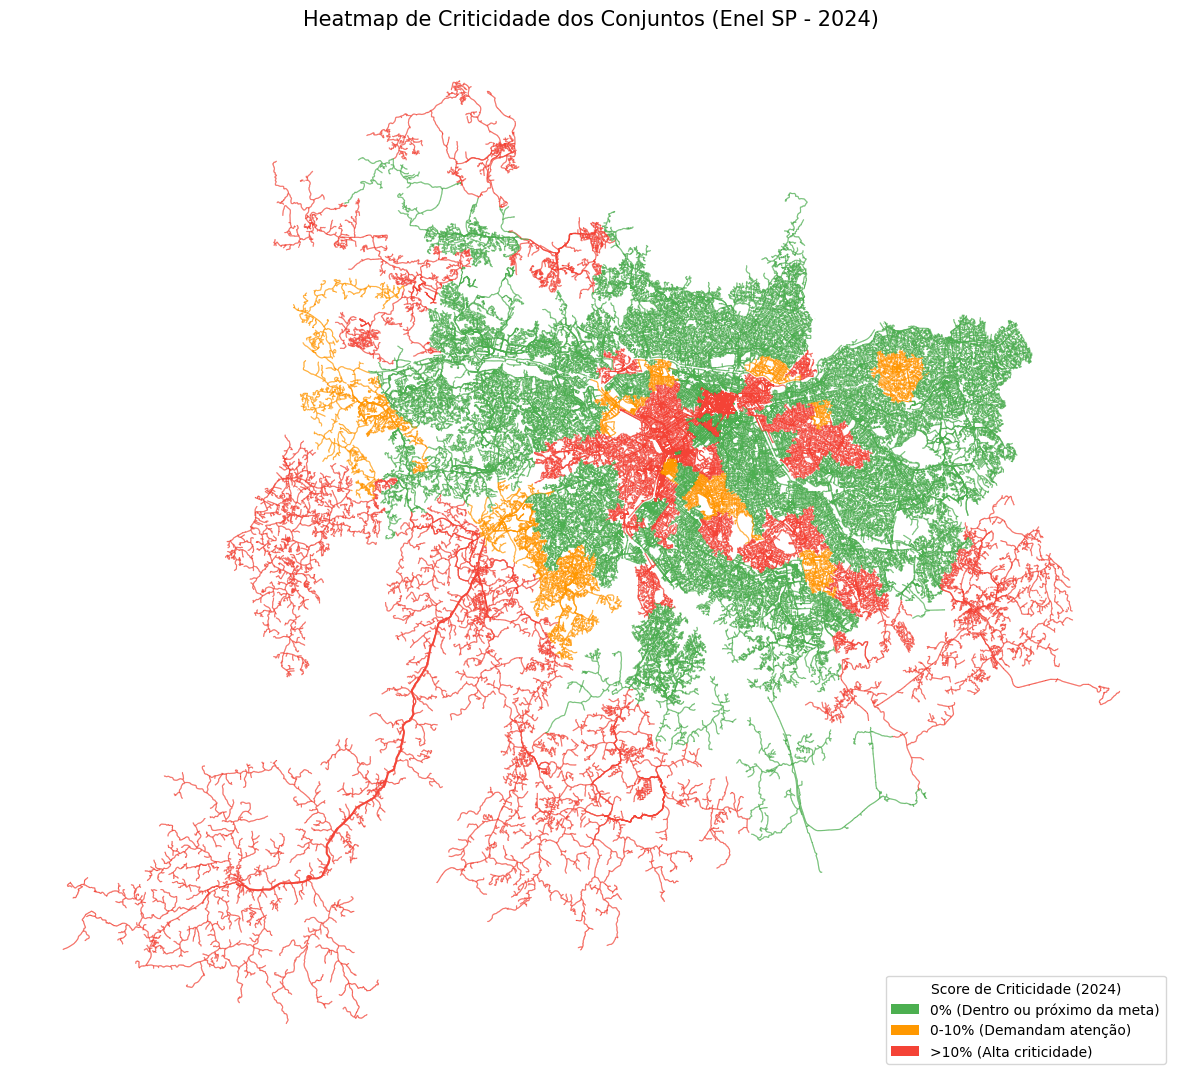

Heatmap de criticidade com cores personalizadas gerado com sucesso!


In [ ]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import numpy as np

# Definir as categorias de criticidade com base na lógica fornecida
def classificar_criticidade(score):
    if score == 0:
        return 'Verde'
    elif 0 < score <= 10:
        return 'Laranja'
    else:
        return 'Vermelho'

gdf_merged['Categoria_Criticidade'] = gdf_merged['Score_Criticidade'].apply(classificar_criticidade)

# Definir um mapeamento de cores para as categorias
cor_map = {
    'Verde': '#4CAF50',  # Verde para 0% (dentro ou próximo da meta)
    'Laranja': '#FF9800', # Laranja para 0-10% (atenção)
    'Vermelho': '#F44336' # Vermelho para >10% (alta criticidade)
}

# Mapear as categorias para cores para plotagem
gdf_merged['Cor_Plotagem'] = gdf_merged['Categoria_Criticidade'].map(cor_map)

# Criar o heatmap
fig, ax = plt.subplots(1, 1, figsize=(15, 15))

# Plotar o GeoDataFrame mesclado, usando 'Cor_Plotagem' para colorir
gdf_merged.plot(
    color=gdf_merged['Cor_Plotagem'],
    linewidth=0.8,
    ax=ax,
    edgecolor='0.8'
)

# Adicionar título e remover os eixos
ax.set_title('Heatmap de Criticidade dos Conjuntos (Enel SP - 2024)', fontsize=15)
ax.set_axis_off()

# Criar uma legenda manual
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=cor_map['Verde'], label='0% (Dentro ou próximo da meta)'),
    Patch(facecolor=cor_map['Laranja'], label='0-10% (Demandam atenção)'),
    Patch(facecolor=cor_map['Vermelho'], label='>10% (Alta criticidade)')
]
ax.legend(handles=legend_elements, title='Score de Criticidade (2024)', loc='lower right')

plt.show()
print("Heatmap de criticidade com cores personalizadas gerado com sucesso!")